# 08 Parameter Sensitivity Analysis

Analyze the TF-IDF + Logistic Regression quick tuning results without retraining any model.

## 1. Imports and Path Setup

Set up libraries, project paths, and output folders.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')

current_dir = Path.cwd().resolve()
if current_dir.name.lower() == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

logs_dir = project_root / 'outputs' / 'logs'
figures_dir = project_root / 'outputs' / 'figures'
report_dir = project_root / 'report'

logs_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
report_dir.mkdir(parents=True, exist_ok=True)

tuning_results_path = logs_dir / 'tfidf_lr_tuning_results.csv'
summary_path = logs_dir / 'parameter_sensitivity_summary.csv'
report_path = report_dir / 'parameter_sensitivity.md'

print(f'Project root: {project_root}')
print(f'Tuning results exists: {tuning_results_path.exists()} -> {tuning_results_path}')

Project root: D:\LLM_Classification_finetuning
Tuning results exists: True -> D:\LLM_Classification_finetuning\outputs\logs\tfidf_lr_tuning_results.csv


## 2. Read Tuning Results

Load the existing quick tuning results and inspect the data.

In [2]:
tuning_results = pd.read_csv(tuning_results_path, encoding='utf-8-sig')

print(f'tuning_results shape: {tuning_results.shape}')
print('tuning_results columns:')
print(tuning_results.columns.tolist())

display(tuning_results.head())

tuning_results shape: (30, 6)
tuning_results columns:
['max_features', 'ngram_range', 'C', 'valid_log_loss', 'valid_accuracy', 'valid_macro_f1']


,max_features,ngram_range,C,valid_log_loss,valid_accuracy,valid_macro_f1
0,100000,"(1, 2)",0.1,1.080877,0.385264,0.383576
1,50000,"(1, 2)",0.1,1.080992,0.386743,0.385398
2,30000,"(1, 2)",0.1,1.081413,0.383873,0.382800
3,100000,"(1, 1)",0.1,1.082040,0.388222,0.387130
4,50000,"(1, 1)",0.1,1.082224,0.387961,0.386762


## 3. Top Results

Sort by validation log loss and show the top 10 parameter combinations.

In [3]:
tuning_results_sorted = tuning_results.sort_values('valid_log_loss', ascending=True).reset_index(drop=True)
top10_results = tuning_results_sorted.head(10)

print('Top 10 results by valid_log_loss:')
display(top10_results)

Top 10 results by valid_log_loss:


,max_features,ngram_range,C,valid_log_loss,valid_accuracy,valid_macro_f1
0,100000,"(1, 2)",0.10,1.080877,0.385264,0.383576
1,50000,"(1, 2)",0.10,1.080992,0.386743,0.385398
2,30000,"(1, 2)",0.10,1.081413,0.383873,0.382800
3,100000,"(1, 1)",0.10,1.082040,0.388222,0.387130
4,50000,"(1, 1)",0.10,1.082224,0.387961,0.386762
5,30000,"(1, 2)",0.05,1.082398,0.385090,0.381421
6,50000,"(1, 2)",0.05,1.082474,0.384047,0.379789
7,30000,"(1, 1)",0.10,1.082495,0.386917,0.386125
8,100000,"(1, 2)",0.30,1.082724,0.387700,0.387914
9,100000,"(1, 2)",0.05,1.082830,0.384916,0.379370


## 4. Sensitivity Tables

Summarize the best validation log loss for each C, max_features, and ngram_range value.

In [4]:
def best_rows_by_parameter(df, parameter):
    idx = df.groupby(parameter)['valid_log_loss'].idxmin()
    columns = list(dict.fromkeys([parameter, 'valid_log_loss', 'valid_accuracy', 'valid_macro_f1', 'max_features', 'ngram_range', 'C']))
    result = df.loc[idx, columns].sort_values(parameter).reset_index(drop=True)
    return result


c_summary = best_rows_by_parameter(tuning_results, 'C')
max_features_summary = best_rows_by_parameter(tuning_results, 'max_features')
ngram_summary = best_rows_by_parameter(tuning_results, 'ngram_range')

print('Best result by C:')
display(c_summary)

print('Best result by max_features:')
display(max_features_summary)

print('Best result by ngram_range:')
display(ngram_summary)

Best result by C:


,C,valid_log_loss,valid_accuracy,valid_macro_f1,max_features,ngram_range
0,0.05,1.082398,0.385090,0.381421,30000,"(1, 2)"
1,0.10,1.080877,0.385264,0.383576,100000,"(1, 2)"
2,0.30,1.082724,0.387700,0.387914,100000,"(1, 2)"
3,0.50,1.088126,0.383525,0.383863,100000,"(1, 2)"
4,1.00,1.104780,0.381698,0.382217,100000,"(1, 2)"


Best result by max_features:


,max_features,valid_log_loss,valid_accuracy,valid_macro_f1,ngram_range,C
0,30000,1.081413,0.383873,0.382800,"(1, 2)",0.1
1,50000,1.080992,0.386743,0.385398,"(1, 2)",0.1
2,100000,1.080877,0.385264,0.383576,"(1, 2)",0.1


Best result by ngram_range:


,ngram_range,valid_log_loss,valid_accuracy,valid_macro_f1,max_features,C
0,"(1, 1)",1.082040,0.388222,0.387130,100000,0.1
1,"(1, 2)",1.080877,0.385264,0.383576,100000,0.1


## 5. Save Summary Table

Combine the sensitivity summaries into one CSV file.

In [5]:
summary_tables = []

for name, table in [
    ('C', c_summary),
    ('max_features', max_features_summary),
    ('ngram_range', ngram_summary),
]:
    table_copy = table.copy()
    table_copy.insert(0, 'sensitivity_parameter', name)
    table_copy = table_copy.rename(columns={name: 'parameter_value'})
    summary_tables.append(table_copy)

parameter_sensitivity_summary = pd.concat(summary_tables, ignore_index=True)
parameter_sensitivity_summary.to_csv(summary_path, index=False, encoding='utf-8-sig')

print(f'Saved summary table: {summary_path}')
display(parameter_sensitivity_summary)

Saved summary table: D:\LLM_Classification_finetuning\outputs\logs\parameter_sensitivity_summary.csv


,sensitivity_parameter,parameter_value,valid_log_loss,valid_accuracy,valid_macro_f1,max_features,ngram_range,C
0,C,0.05,1.082398,0.385090,0.381421,30000.0,"(1, 2)",NaN
1,C,0.1,1.080877,0.385264,0.383576,100000.0,"(1, 2)",NaN
2,C,0.3,1.082724,0.387700,0.387914,100000.0,"(1, 2)",NaN
3,C,0.5,1.088126,0.383525,0.383863,100000.0,"(1, 2)",NaN
4,C,1.0,1.104780,0.381698,0.382217,100000.0,"(1, 2)",NaN
5,max_features,30000,1.081413,0.383873,0.382800,NaN,"(1, 2)",0.1
6,max_features,50000,1.080992,0.386743,0.385398,NaN,"(1, 2)",0.1
7,max_features,100000,1.080877,0.385264,0.383576,NaN,"(1, 2)",0.1
8,ngram_range,"(1, 1)",1.082040,0.388222,0.387130,100000.0,NaN,0.1
9,ngram_range,"(1, 2)",1.080877,0.385264,0.383576,100000.0,NaN,0.1


## 6. Plot C Sensitivity

Plot C versus the best validation log loss achieved at that C value.

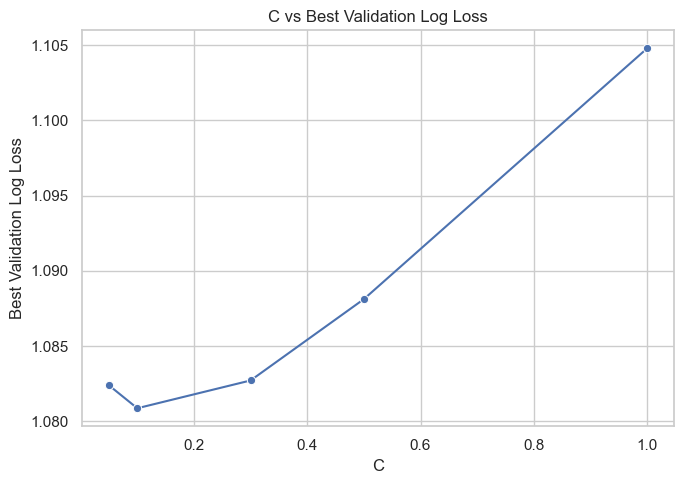

Saved figure: D:\LLM_Classification_finetuning\outputs\figures\sensitivity_C_log_loss.png


In [6]:
plt.figure(figsize=(7, 5))
sns.lineplot(data=c_summary, x='C', y='valid_log_loss', marker='o')
plt.title('C vs Best Validation Log Loss')
plt.xlabel('C')
plt.ylabel('Best Validation Log Loss')
plt.tight_layout()

c_figure_path = figures_dir / 'sensitivity_C_log_loss.png'
plt.savefig(c_figure_path, dpi=150)
plt.show()

print(f'Saved figure: {c_figure_path}')

## 7. Plot max_features Sensitivity

Plot max_features versus the best validation log loss achieved at that vocabulary size.

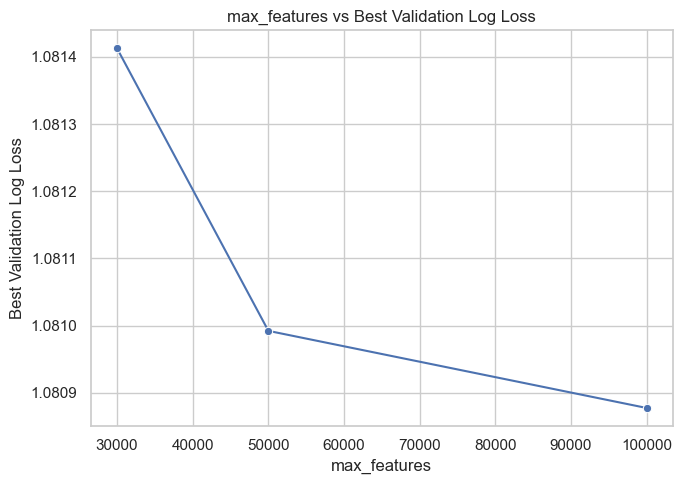

Saved figure: D:\LLM_Classification_finetuning\outputs\figures\sensitivity_max_features_log_loss.png


In [7]:
plt.figure(figsize=(7, 5))
sns.lineplot(data=max_features_summary, x='max_features', y='valid_log_loss', marker='o')
plt.title('max_features vs Best Validation Log Loss')
plt.xlabel('max_features')
plt.ylabel('Best Validation Log Loss')
plt.tight_layout()

max_features_figure_path = figures_dir / 'sensitivity_max_features_log_loss.png'
plt.savefig(max_features_figure_path, dpi=150)
plt.show()

print(f'Saved figure: {max_features_figure_path}')

## 8. Plot ngram_range Sensitivity

Plot ngram_range versus the best validation log loss achieved with that feature setting.

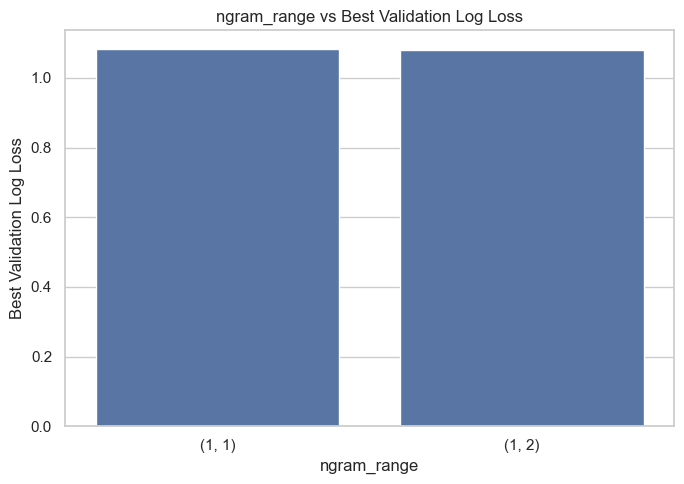

Saved figure: D:\LLM_Classification_finetuning\outputs\figures\sensitivity_ngram_log_loss.png


In [8]:
plt.figure(figsize=(7, 5))
sns.barplot(data=ngram_summary, x='ngram_range', y='valid_log_loss')
plt.title('ngram_range vs Best Validation Log Loss')
plt.xlabel('ngram_range')
plt.ylabel('Best Validation Log Loss')
plt.tight_layout()

ngram_figure_path = figures_dir / 'sensitivity_ngram_log_loss.png'
plt.savefig(ngram_figure_path, dpi=150)
plt.show()

print(f'Saved figure: {ngram_figure_path}')

## 9. Write Markdown Report

Generate a concise Markdown conclusion for the course report.

In [9]:
best_row = tuning_results_sorted.iloc[0]
best_c_row = c_summary.sort_values('valid_log_loss').iloc[0]
best_max_features_row = max_features_summary.sort_values('valid_log_loss').iloc[0]
best_ngram_row = ngram_summary.sort_values('valid_log_loss').iloc[0]

report_text = f"""# Parameter Sensitivity Analysis

This section analyzes the TF-IDF + Logistic Regression quick tuning results. The tuning grid covered max_features values of 30000, 50000, and 100000; ngram_range values of (1, 1) and (1, 2); and C values of 0.05, 0.1, 0.3, 0.5, and 1.0.

## Best Configuration

The best validation result was obtained with:

- max_features = {int(best_row['max_features'])}
- ngram_range = {best_row['ngram_range']}
- C = {best_row['C']}
- valid_log_loss = {best_row['valid_log_loss']:.6f}
- valid_accuracy = {best_row['valid_accuracy']:.6f}
- valid_macro_f1 = {best_row['valid_macro_f1']:.6f}

## Conclusions

- C=0.1 achieved the lowest log loss in the tuning grid. This suggests that a moderate amount of regularization is important for this sparse high-dimensional TF-IDF model.
- When C becomes too large, log loss becomes worse, which indicates that insufficient regularization can make the model over-confident.
- ngram_range=(1, 2) is generally better than unigram-only features, showing that bigram phrase features are useful for capturing response quality patterns.
- max_features=100000 gives the best or a very strong result, suggesting that a larger vocabulary helps capture more text patterns in prompts and responses.
- Therefore, the final tuned baseline uses max_features=100000, ngram_range=(1, 2), and C=0.1.

## Best Per-Parameter Results

- Best C setting: C={best_c_row['C']}, valid_log_loss={best_c_row['valid_log_loss']:.6f}
- Best max_features setting: max_features={int(best_max_features_row['max_features'])}, valid_log_loss={best_max_features_row['valid_log_loss']:.6f}
- Best ngram_range setting: ngram_range={best_ngram_row['ngram_range']}, valid_log_loss={best_ngram_row['valid_log_loss']:.6f}
"""

report_path.write_text(report_text, encoding='utf-8')

print(f'Saved report: {report_path}')
print(report_text)

Saved report: D:\LLM_Classification_finetuning\report\parameter_sensitivity.md
# Parameter Sensitivity Analysis

This section analyzes the TF-IDF + Logistic Regression quick tuning results. The tuning grid covered max_features values of 30000, 50000, and 100000; ngram_range values of (1, 1) and (1, 2); and C values of 0.05, 0.1, 0.3, 0.5, and 1.0.

## Best Configuration

The best validation result was obtained with:

- max_features = 100000
- ngram_range = (1, 2)
- C = 0.1
- valid_log_loss = 1.080877
- valid_accuracy = 0.385264
- valid_macro_f1 = 0.383576

## Conclusions

- C=0.1 achieved the lowest log loss in the tuning grid. This suggests that a moderate amount of regularization is important for this sparse high-dimensional TF-IDF model.
- When C becomes too large, log loss becomes worse, which indicates that insufficient regularization can make the model over-confident.
- ngram_range=(1, 2) is generally better than unigram-only features, showing that bigram phrase features are usef

## 10. Final Checks

Check output files and finish.

In [10]:
print('Saved outputs:')
for path in [
    summary_path,
    c_figure_path,
    max_features_figure_path,
    ngram_figure_path,
    report_path,
]:
    print(f'{path.exists()} -> {path}')

print('Parameter sensitivity analysis finished successfully.')

Saved outputs:
True -> D:\LLM_Classification_finetuning\outputs\logs\parameter_sensitivity_summary.csv
True -> D:\LLM_Classification_finetuning\outputs\figures\sensitivity_C_log_loss.png
True -> D:\LLM_Classification_finetuning\outputs\figures\sensitivity_max_features_log_loss.png
True -> D:\LLM_Classification_finetuning\outputs\figures\sensitivity_ngram_log_loss.png
True -> D:\LLM_Classification_finetuning\report\parameter_sensitivity.md
Parameter sensitivity analysis finished successfully.
